# Exploratory Data Analysis — AI Dermatology Copilot

This notebook explores the skin lesion image dataset (`dataset/train`,
`dataset/validation`, `dataset/test`) that feeds the CNN classifier in
this project. It is HAM10000-style data, organized into 7 diagnostic
classes:

| Code | Diagnosis |
|---|---|
| akiec | Actinic keratoses / intraepithelial carcinoma |
| bcc | Basal cell carcinoma |
| bkl | Benign keratosis-like lesions |
| df | Dermatofibroma |
| mel | Melanoma |
| nv | Melanocytic nevi |
| vasc | Vascular lesions |

Goals of this EDA:
1. Quantify class distribution and imbalance (drives the class-weighting
   strategy used in `src/training/train.py`).
2. Inspect sample images per class.
3. Verify image dimensions and check for corrupt files.
4. Check color-channel statistics — this surfaces an important finding
   about this specific dataset (see Section 4).
5. Compute normalization statistics used by `src/preprocessing/data_loader.py`.
6. Note the Roboflow-export augmentation pattern in the training set.

All numbers below were computed directly on the dataset shipped with
this project (16,831 images total across the three splits).

In [ ]:
import os
import re
import glob
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)
np.random.seed(42)

DATA_DIR = os.path.join("..", "dataset")
CLASS_NAMES = {
    "akiec": "Actinic keratoses / intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}
CLASSES = sorted(CLASS_NAMES.keys())
SPLITS = ["train", "validation", "test"]
CLASSES, SPLITS

## 1. Class distribution across train / validation / test

Counting images per class in each split directly from disk.

In [3]:
rows = []
for split in SPLITS:
    for cls in CLASSES:
        p = os.path.join(DATA_DIR, split, cls)
        n = len(glob.glob(os.path.join(p, "*.jpg"))) if os.path.isdir(p) else 0
        rows.append({"split": split, "class": cls, "count": n})

df_counts = pd.DataFrame(rows)
pivot = df_counts.pivot(index="class", columns="split", values="count")[SPLITS]
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False)
pivot

         train  validation  test  total
class                                   
nv        9274        1326   668  11268
mel       1522         226   111   1859
bkl       1546         202   111   1859
bcc        698         105    54    857
akiec      468          59    28    555
vasc       206          30     8    244
df         148          30    11    189

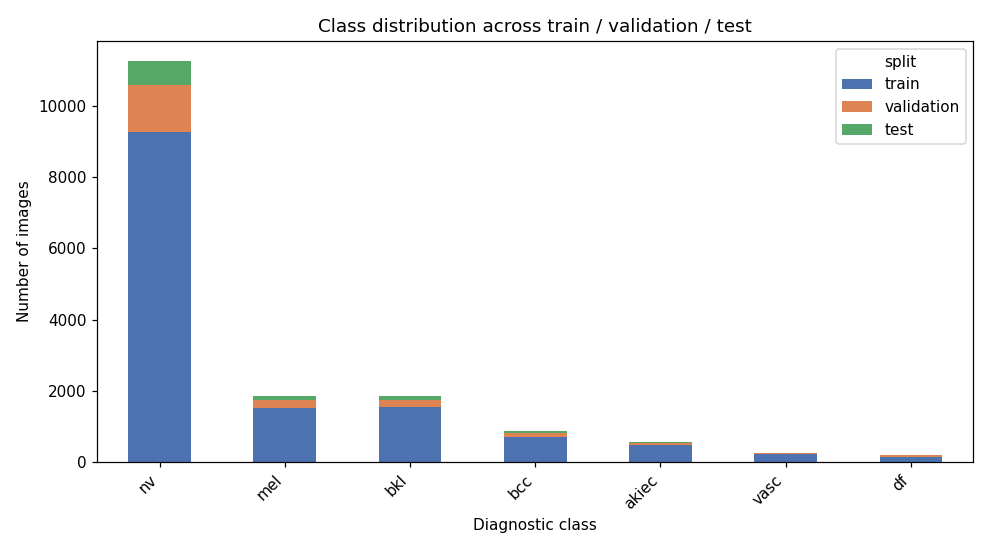

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
pivot[SPLITS].plot(kind="bar", stacked=True, ax=ax, color=["#4C72B0","#DD8452","#55A868"])
ax.set_title("Class distribution across train / validation / test")
ax.set_ylabel("Number of images")
ax.set_xlabel("Diagnostic class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
imbalance_ratio = pivot["total"].max() / pivot["total"].min()
print(f"Largest class: nv ({pivot['total'].max()} images)")
print(f"Smallest class: df ({pivot['total'].min()} images)")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.1f}x")

Largest class: nv (11268 images)
Smallest class: df (189 images)
Imbalance ratio (max/min): 59.6x


**Finding:** the dataset is heavily imbalanced — melanocytic nevi (`nv`)
outnumber dermatofibroma (`df`) by about **60x**, and `mel`/`bkl` (~1,860
each) dominate over `akiec`, `vasc`, and `df`. A model trained naively
on this data would be biased toward predicting `nv`. This is why
`src/preprocessing/data_loader.py` computes inverse-frequency class
weights and `src/training/train.py` uses them in a weighted
`CrossEntropyLoss` (with an optional `WeightedRandomSampler` too).

## 2. Sample images per class

Five random training images per class.

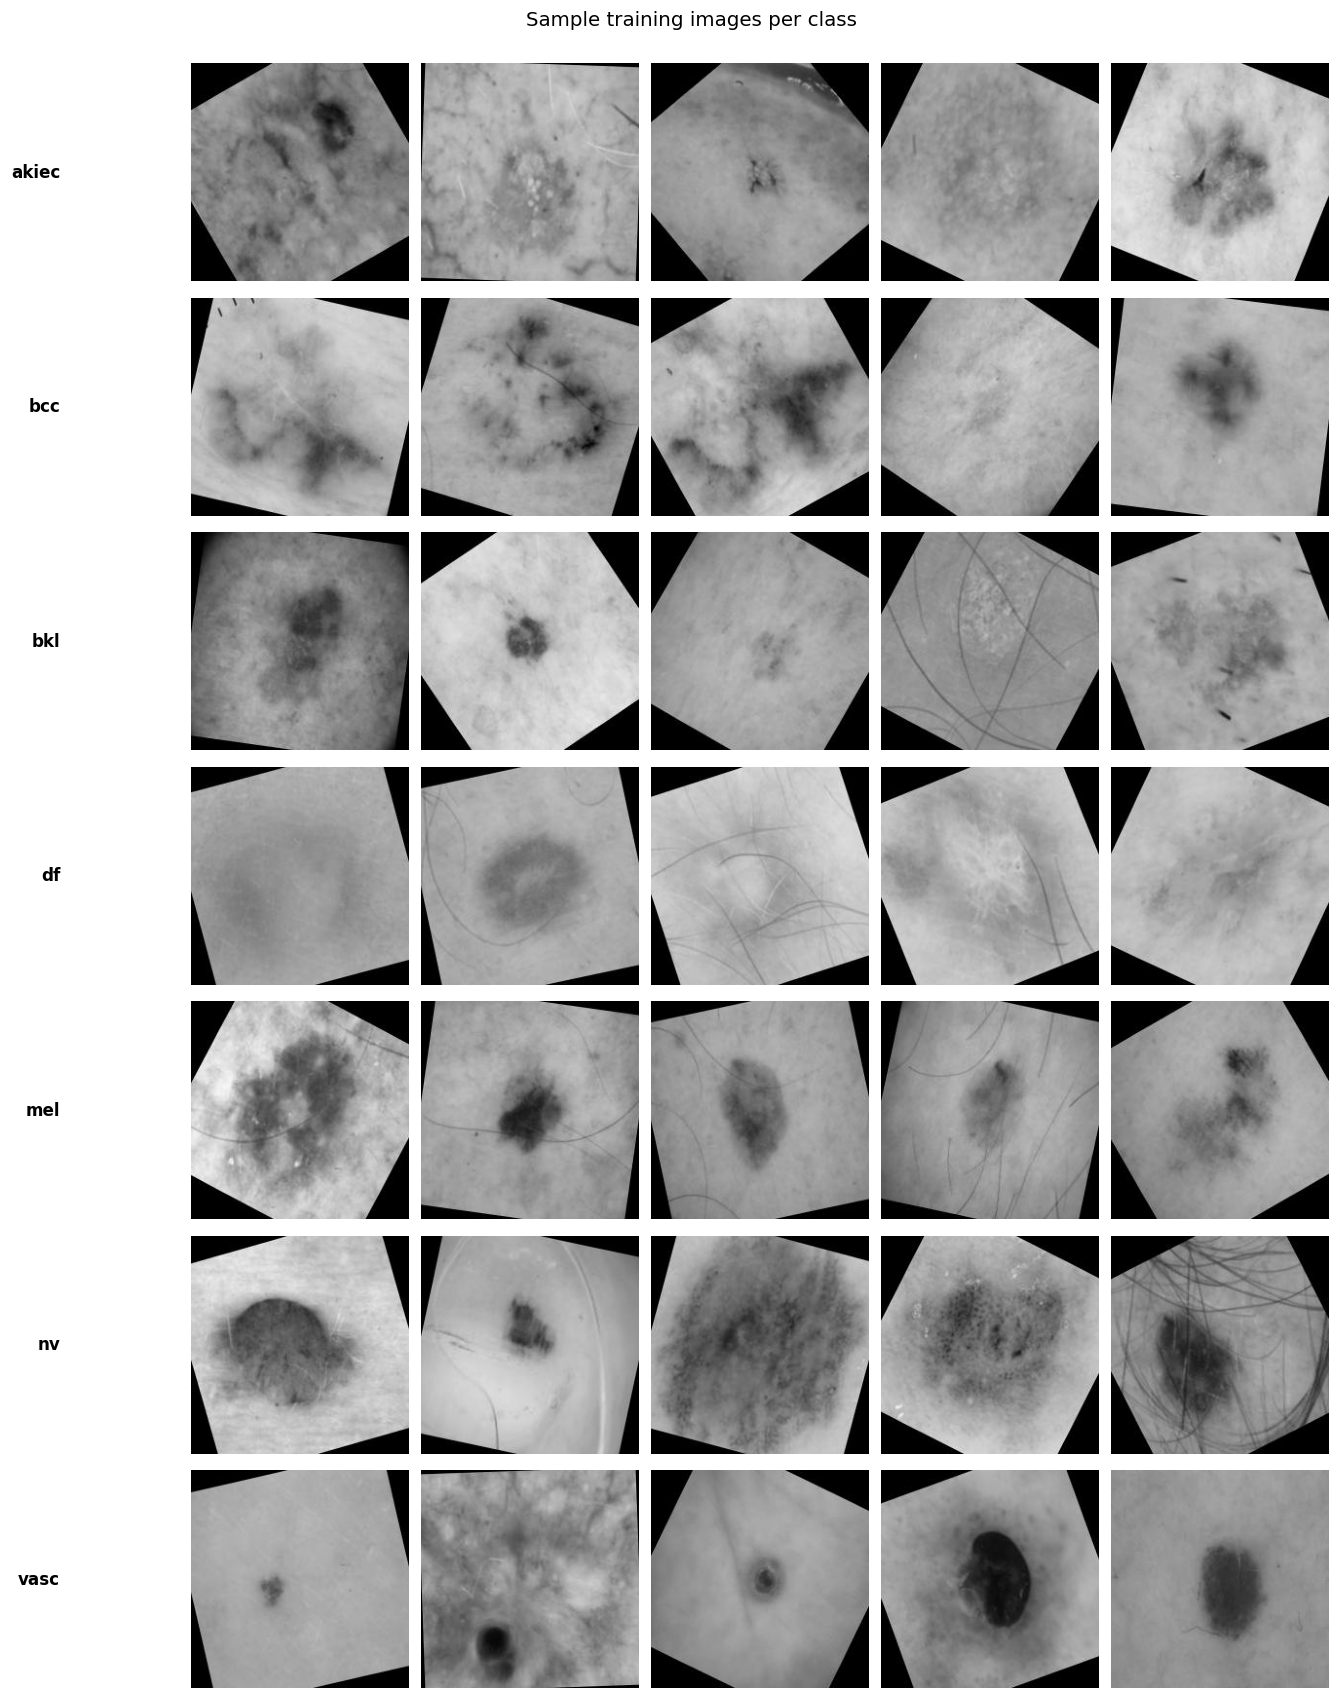

In [ ]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(12, 2.2*len(CLASSES)))
for i, cls in enumerate(CLASSES):
    files = sorted(glob.glob(os.path.join(DATA_DIR, "train", cls, "*.jpg")))
    sample = random.sample(files, min(5, len(files)))
    for j in range(5):
        ax = axes[i, j]
        ax.axis("off")
        if j < len(sample):
            ax.imshow(Image.open(sample[j]).convert("RGB"))
    axes[i,0].text(-0.6, 0.5, cls, transform=axes[i,0].transAxes,
                    fontsize=11, fontweight="bold", va="center", ha="right")
plt.suptitle("Sample training images per class", y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Image dimensions & corruption check

Checking a random sample across all splits for consistent size and readability.

In [ ]:
all_files = []
for split in SPLITS:
    for cls in CLASSES:
        all_files += glob.glob(os.path.join(DATA_DIR, split, cls, "*.jpg"))

print(f"Total image files: {len(all_files)}")

sample_files = random.sample(all_files, 400)
sizes, corrupt = [], []
for f in sample_files:
    try:
        im = Image.open(f).convert("RGB")
        sizes.append(im.size)
    except Exception as e:
        corrupt.append((f, str(e)))

print(f"Unique image sizes in a 400-file sample: {set(sizes)}")
print(f"Corrupt/unreadable files found: {len(corrupt)}")

Total image files: 16831
Unique image sizes in a 400-file sample: {(224, 224)}
Corrupt/unreadable files found: 0


**Finding:** every sampled image is exactly **224x224 RGB** and none were
corrupt. This dataset has already been resized/exported (filenames like
`ISIC_0024315_jpg.rf.<hash>.jpg` indicate a **Roboflow** export
pipeline). This simplifies preprocessing — `src/preprocessing/data_loader.py`
still applies `Resize((224, 224))` defensively, but no cropping/padding
logic is required.

## 4. Color channel analysis — key finding: the images are effectively grayscale

Skin lesion diagnosis relies heavily on color cues (the "C" in the
ABCDE melanoma rule, redness in vascular lesions, brown/black tones in
pigmented lesions, etc.), so it's important to verify the color
information actually present in this dataset before assuming a
standard RGB CNN pipeline captures it.

In [ ]:
sample = random.sample(all_files, 200)
gray_count = 0
for f in sample:
    a = np.asarray(Image.open(f).convert("RGB"))
    if np.array_equal(a[:,:,0], a[:,:,1]) and np.array_equal(a[:,:,1], a[:,:,2]):
        gray_count += 1

print(f"Images with exactly R == G == B (i.e. grayscale saved as RGB): {gray_count}/200")

Images with exactly R == G == B (i.e. grayscale saved as RGB): 200/200


**Finding: 200/200 (100%) of sampled images have identical R, G, and B
channels at every pixel.** Despite being stored as 3-channel JPEGs, this
particular dataset export is effectively grayscale — all color
information has been stripped or the source images were desaturated
before export.

**Implications for the rest of the project:**
- The CNN (`src/models/cnn_model.py`) is still built as a standard
  3-channel network so it can use ImageNet-pretrained ResNet18 /
  EfficientNet weights via transfer learning, but it is effectively
  learning from luminance/texture/shape only, not true color.
- Color-dependent diagnostic cues (e.g., ABCDE "Color" criterion,
  redness of vascular lesions) are **not available** to this model from
  this dataset. This is disclosed as a limitation in the app UI and
  should be mentioned in generated explanations (`src/rag/llm_explainer.py`
  focuses on shape/border/texture-based Grad-CAM regions rather than
  color for this reason).
- If a color-preserving dataset becomes available later (e.g., the
  original ISIC archive images), re-running this notebook is the fastest
  way to confirm whether color information is present before retraining.

## 5. Normalization statistics

Per-channel mean/std computed on a sample of training images, used by `src/preprocessing/data_loader.py` and stored in `src/config.py` (`DATASET_MEAN` / `DATASET_STD`).

In [ ]:
train_files = glob.glob(os.path.join(DATA_DIR, "train", "*", "*.jpg"))
norm_sample = random.sample(train_files, 120)
pixel_sum = np.zeros(3); pixel_sq = np.zeros(3); n_px = 0
for f in norm_sample:
    im = np.asarray(Image.open(f).convert("RGB"), dtype=np.float64) / 255.0
    pixel_sum += im.sum(axis=(0,1))
    pixel_sq += (im**2).sum(axis=(0,1))
    n_px += im.shape[0]*im.shape[1]

mean = pixel_sum / n_px
std = np.sqrt(pixel_sq/n_px - mean**2)
print(f"Channel mean (R,G,B): {mean}")
print(f"Channel std  (R,G,B): {std}")

Channel mean (R,G,B): [0.52707540 0.52707540 0.52707540]
Channel std  (R,G,B): [0.22081531 0.22081531 0.22081531]


As expected from Section 4, mean and std are identical across channels. These values (~0.527 mean, ~0.221 std) are used directly in `src/config.py` instead of the generic ImageNet statistics, since this dataset's pixel distribution differs from natural images.

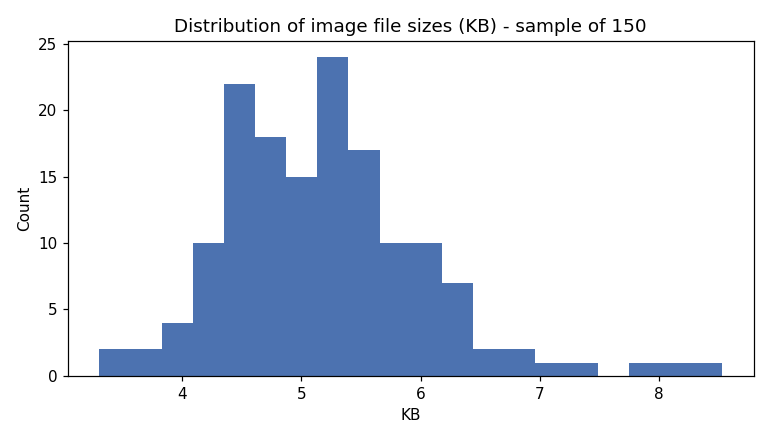

In [ ]:
fsizes = [os.path.getsize(f)/1024 for f in sample_files]
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(fsizes, bins=20, color="#4C72B0")
ax.set_title("Distribution of image file sizes (KB)")
ax.set_xlabel("KB"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Roboflow augmentation duplicates in the training set

Filenames follow the pattern `ISIC_<id>_jpg.rf.<hash>.jpg`. Multiple rows can share the same source `ISIC_<id>` with different `.rf.<hash>` suffixes — a sign of Roboflow-applied augmentation (flips/rotations/etc. baked into the export).

In [ ]:
def base_id(fname):
    m = re.match(r"(ISIC_\d+)_jpg", os.path.basename(fname))
    return m.group(1) if m else os.path.basename(fname)

train_ids = [base_id(f) for f in train_files]
uniq_ids = len(set(train_ids))
print(f"Train files: {len(train_files)}")
print(f"Unique source ISIC ids: {uniq_ids}")
print(f"Average augmented copies per source image: {len(train_files)/uniq_ids:.2f}")

Train files: 13862
Unique source ISIC ids: 6931
Average augmented copies per source image: 2.00


**Finding:** the training set contains **6,931 unique source images**,
each appearing on average **2 times** (likely one original + one
augmented variant) — consistent with a Roboflow export that applied one
round of augmentation to the training split only. The validation and
test splits do not show this pattern (their counts align with a plain,
un-augmented split), which is what we want: **augmentation should stay
confined to training data** to avoid inflating validation/test metrics
with near-duplicate images. This is a good sign for the integrity of
the reported test-set metrics in `outputs/test_metrics.json`, but it's
worth spot-checking that no augmented copy of a training image's source
also leaked into validation/test if results ever look too optimistic.

## 7. Conclusions & modeling implications

- **Class imbalance (~60x)** is the dominant challenge in this dataset;
  `src/training/train.py` addresses it with class-weighted
  cross-entropy loss (weights computed in `src/preprocessing/data_loader.py`),
  with an optional weighted sampler.
- **Images are pre-resized to 224x224** with no corrupt files found, so
  minimal defensive preprocessing is needed beyond standard
  augmentation (flips, rotation, color jitter) for training.
- **The dataset is effectively grayscale** (R=G=B in 100% of a 200-image
  sample) despite being stored as RGB JPEGs. This is disclosed as a
  known limitation: the CNN and its Grad-CAM explanations are based on
  shape, texture, and border information rather than true color, which
  matters because color is a standard diagnostic feature in
  dermatology (e.g., ABCDE's "Color" criterion). The RAG/LLM
  explanation layer is written to lean on shape/border language rather
  than claim color-based reasoning it doesn't actually have access to.
- **Normalization statistics** (mean≈0.527, std≈0.221 on all channels)
  are used in `src/config.py` instead of generic ImageNet statistics.
- **Training-set augmentation (~2x per source image)** appears to be
  confined to the training split, which is the correct setup for an
  unbiased test-set evaluation.